In [12]:
import duckdb
from matplotlib import pyplot as plt
import seaborn as sns

from fantasy_football.constants import DATA_FOLDER
from fantasy_football.storage.lookups import register_lookups
from fantasy_football.features.match_form import register_match_form
from fantasy_football.features.team_form import register_team_form

In [6]:
DATABASE_PATH = DATA_FOLDER / "fantasy_football.duckdb"
connection = duckdb.connect(DATABASE_PATH)

In [7]:
register_lookups(connection)
register_match_form(connection)
register_team_form(connection)


1 team_match rows have no kickoff_time and so no position in the rolling window; their fixture is missing from team_fixture.


In [8]:
positions = connection.sql("SELECT DISTINCT position FROM player_season").pl()
positions.head()

position
str
"""MID"""
"""FWD"""
"""DEF"""
"""GK"""
null


In [10]:
base_sql = """
SELECT 
    m.season
    ,s.first_name || ' ' || s.second_name as player_name
    ,m.element
    ,m.total_points
    ,m.kickoff_time
    ,m.gw
    ,m.opponent
    ,m.minutes
    ,m.is_home
    ,mn.expected_minutes
    ,mn.p_zero
    ,mn.p_partial
    ,mn.p_sixty_plus
    ,mf.xg_per90_rolling_5
    ,mf.xa_per90_rolling_5
    ,mf.form_minutes
    ,own.xg_against_rolling_5
    ,own.goals_against_rolling_5
    ,own.clean_sheet_rolling_5
    ,opp.xg_for_rolling_5
    ,opp.goals_for_rolling_5
    ,mf.interceptions_per90_rolling_5
    ,mf.tackles_per90_rolling_5
    ,mf.clearances_per90_rolling_5
    ,mf.blocks_per90_rolling_5
    ,mf.yellow_cards_per90_rolling_5
    ,mf.red_cards_per90_rolling_5
    ,mf.yellow_cards_season_to_date
    ,mf.red_cards_season_to_date

FROM player_match m 

INNER JOIN player_season s ON m.element = s.element
    AND m.season = s.season
    AND s.position = 'FWD'
LEFT JOIN minutes_prediction mn ON m.element = mn.element
    AND m.season = mn.season
    AND m.gw = mn.gw
    AND m.element = mn.element
    AND m.opponent = mn.opponent
LEFT JOIN player_match_form mf ON m.element = mf.element
    AND m.season = mf.season
    AND m.gw = mf.gw
    AND m.opponent = mf.opponent
LEFT JOIN player_week pw ON pw.season = m.season
    AND pw.gw = m.gw
    AND pw.element = m.element
LEFT JOIN fpl_team_id opp_id ON opp_id.season = m.season
    AND opp_id.team_id = m.opponent
LEFT JOIN team_match_form own ON own.season = m.season
    AND own.gw = m.gw
    AND own.team = pw.team
    AND own.opposition = opp_id.team
LEFT JOIN team_match_form opp ON opp.season = m.season
    AND opp.gw = m.gw
    AND opp.team = opp_id.team
    AND opp.opposition = pw.team
"""

base = connection.sql(base_sql).pl()
base.head(10)

season,player_name,element,total_points,kickoff_time,gw,opponent,minutes,is_home,expected_minutes,p_zero,p_partial,p_sixty_plus,xg_per90_rolling_5,xa_per90_rolling_5,form_minutes,xg_against_rolling_5,goals_against_rolling_5,clean_sheet_rolling_5,xg_for_rolling_5,goals_for_rolling_5,interceptions_per90_rolling_5,tackles_per90_rolling_5,clearances_per90_rolling_5,blocks_per90_rolling_5,yellow_cards_per90_rolling_5,red_cards_per90_rolling_5,yellow_cards_season_to_date,red_cards_season_to_date
str,str,i64,i64,datetime[μs],i64,i64,i64,bool,f64,f64,f64,f64,f64,f64,"decimal[38,0]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]"
"""2020-21""","""Ollie Watkins""",514,2,2020-09-21 17:00:00,2,15,90,true,38.409655,0.324562,0.272182,0.403256,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,0
"""2020-21""","""Ollie Watkins""",514,2,2020-09-28 16:45:00,3,8,90,false,38.283981,0.325577,0.273283,0.40114,null,null,90,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,19,2020-10-04 18:15:00,4,11,90,true,38.222298,0.326075,0.273824,0.400101,null,null,180,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,2,2020-10-18 18:15:00,5,9,90,false,38.225431,0.326049,0.273797,0.400154,null,null,270,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,2,2020-10-23 19:00:00,6,10,90,true,38.224385,0.326058,0.273806,0.400136,null,null,360,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,7,2020-11-01 12:00:00,7,16,90,true,38.224385,0.326058,0.273806,0.400136,null,null,450,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,13,2020-11-08 19:15:00,8,1,90,false,38.224385,0.326058,0.273806,0.400136,null,null,450,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,2,2020-11-21 15:00:00,9,3,90,true,38.984089,0.31566,0.274253,0.410087,null,null,450,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2020-21""","""Ollie Watkins""",514,0,2020-11-30 20:00:00,10,19,90,false,38.985156,0.315652,0.274243,0.410105,null,null,450,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0


In [14]:
features = [
    "total_points",
    "is_home",
    "expected_minutes",
    "xg_per90_rolling_5",
    "xa_per90_rolling_5",
    "xg_for_rolling_5",
    "goals_for_rolling_5",
    "interceptions_per90_rolling_5",
    "tackles_per90_rolling_5",
    "clearances_per90_rolling_5",
    "blocks_per90_rolling_5",
    "yellow_cards_per90_rolling_5",
    "red_cards_per90_rolling_5",
    "yellow_cards_season_to_date",
    "red_cards_season_to_date",
]
base = base.select(features)
base.head()

total_points,is_home,expected_minutes,xg_per90_rolling_5,xa_per90_rolling_5,xg_for_rolling_5,goals_for_rolling_5,interceptions_per90_rolling_5,tackles_per90_rolling_5,clearances_per90_rolling_5,blocks_per90_rolling_5,yellow_cards_per90_rolling_5,red_cards_per90_rolling_5,yellow_cards_season_to_date,red_cards_season_to_date
i64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]"
2,true,38.409655,null,null,null,null,null,null,null,null,null,null,0,0
2,false,38.283981,null,null,null,null,null,null,null,null,0.0,0.0,0,0
19,true,38.222298,null,null,null,null,null,null,null,null,0.0,0.0,0,0
2,false,38.225431,null,null,null,null,null,null,null,null,0.0,0.0,0,0
2,true,38.224385,null,null,null,null,null,null,null,null,0.0,0.0,0,0


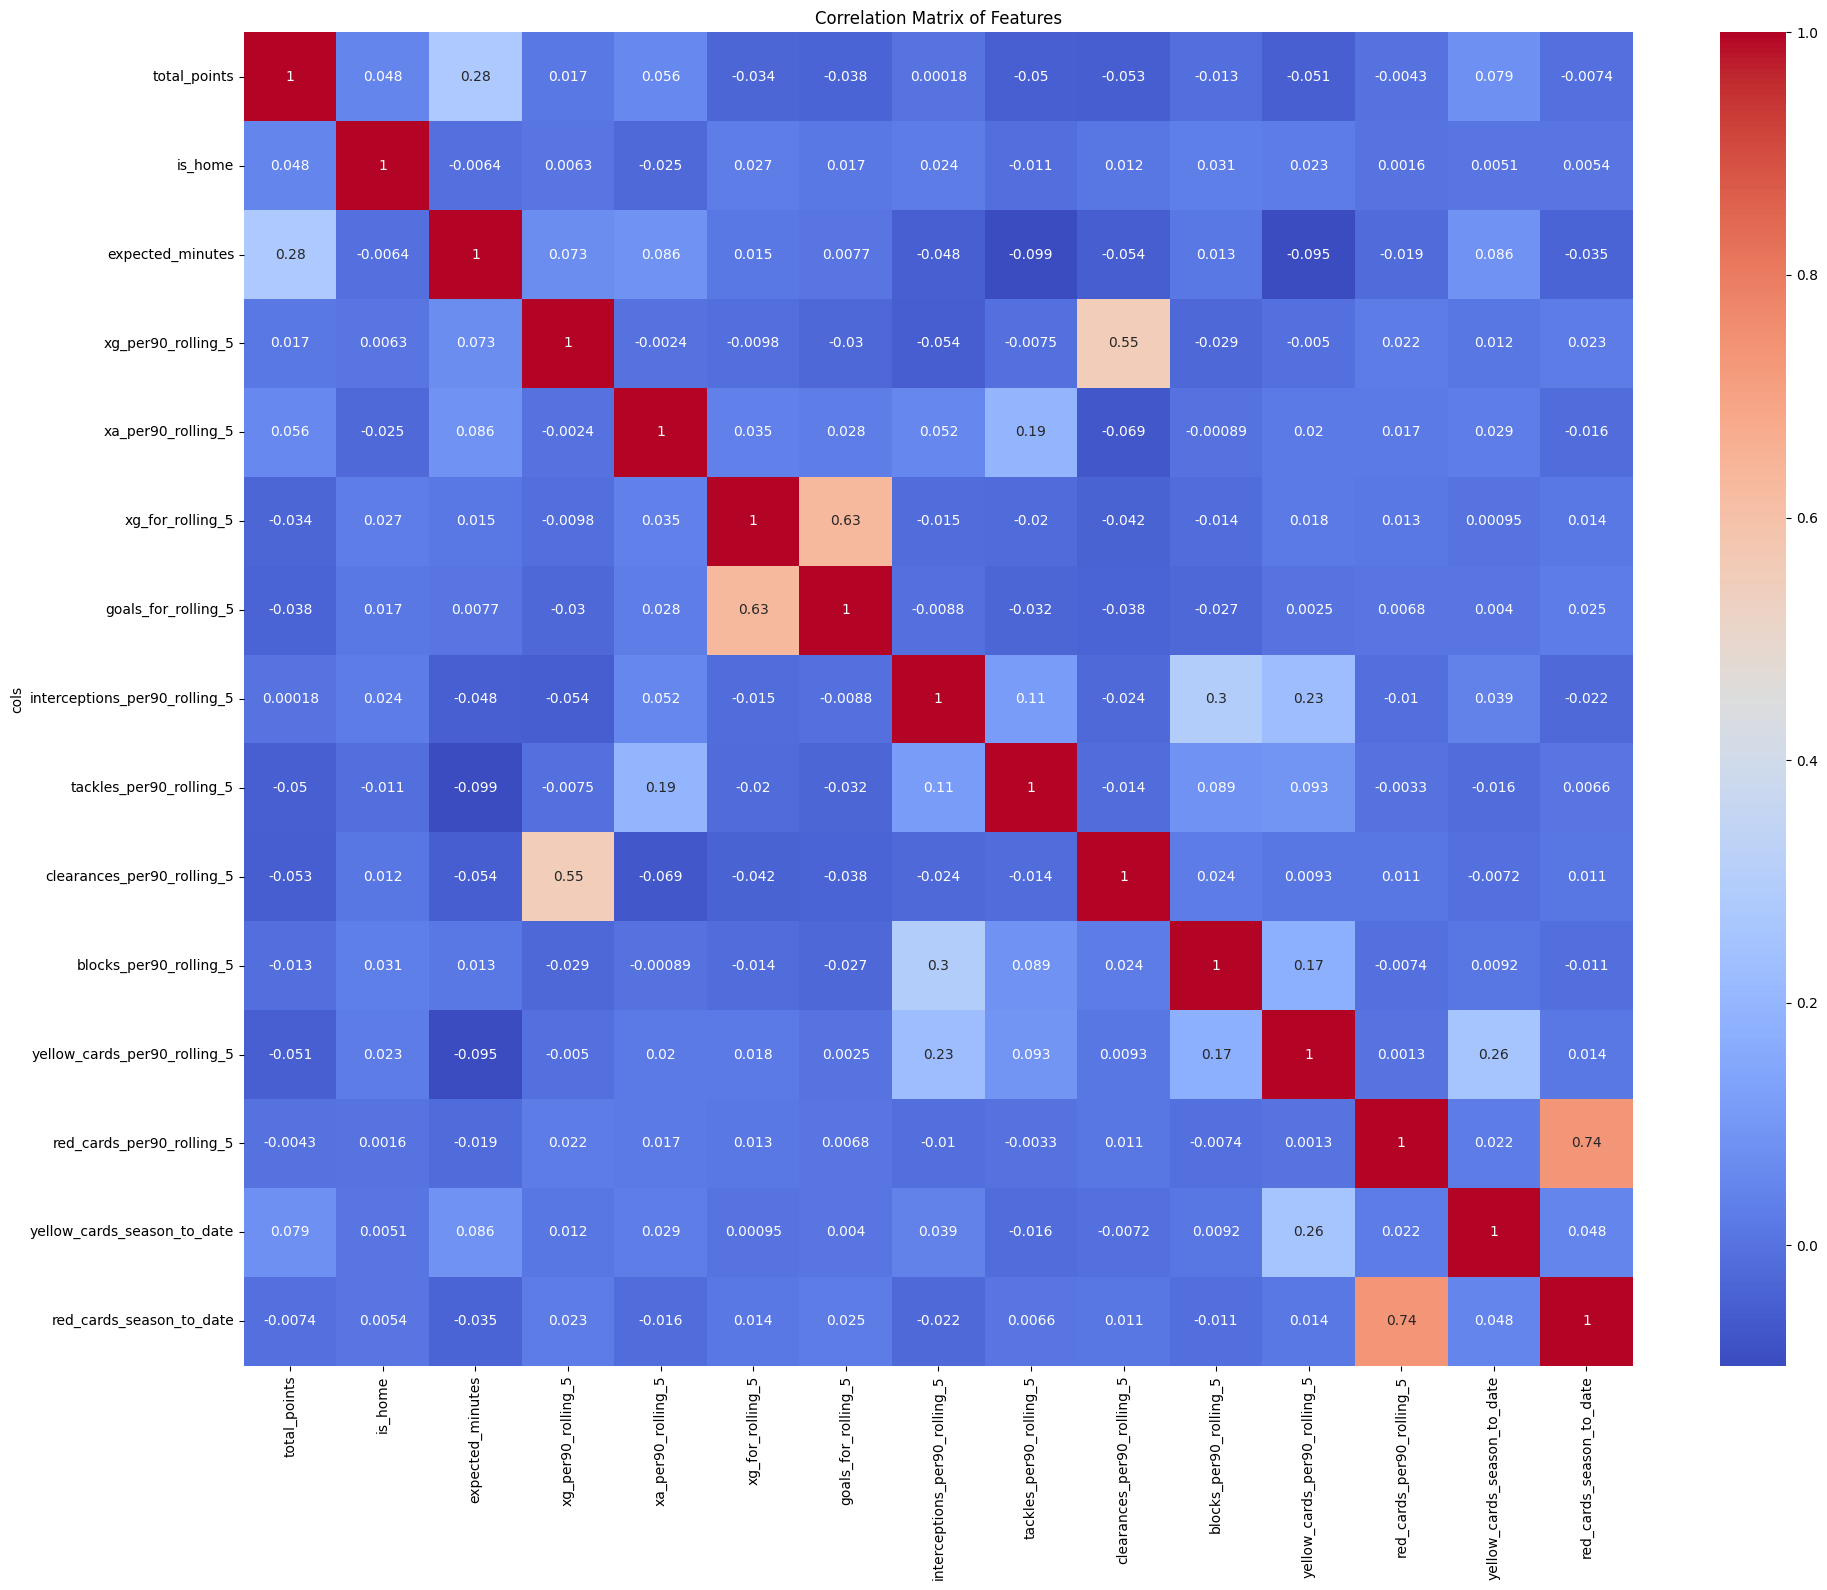

In [15]:
correlation_matrix = base.drop_nulls().corr(label="cols").to_pandas().set_index("cols")

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", ax=ax)
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = base.drop(["total_points"])
y = base["total_points"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.49
MSE: 5.95
RMSE: 2.44


In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.22
MSE: 5.95
RMSE: 2.44
